In this notebook, we will briefly explore the temporal limitations of our method.

The Monthly History dataset provides a single classification for the entire month, based on available cloud-free scenes. It is derived from images taken by Landsat 7 and Landsat 8 satellites, each of which has a 16-day revisit cycle. Landsat 8 was offset 8 days from Landsat 7, so that under ideal conditions, the image is taken once every 8 days. A flood that ocurred after the collapse of the dam could in some areas last hours and days, and thus avoid being captured by the satellites.

Additionally, if the cloud cover or haze persisted during the critical days of the flood, these images would not be included in the creation of the classification, additionally causing underestimation of inundated areas.

To find out if these factors could influence our analysis in this case, I will identify the specific Landsat images that contributed to the creation of the JRC Global Surface Water classification for May 2020.
I will limit my research to the area closest to the dam: the Sirdaryo Region of Uzbekistan.

## Exploration
I identify the satellite images from the Landsat 7 and Landsat 8 of the Sirdaryo Region, masking clouds, cirruses, cloud shadows, snow and ice, and fill pixels. I export the metadata of these images as a .csv for analysis. I then download all images (visible bands) for vizualisation:

In [ ]:
// GEE code
// ================== Inputs ==================
var AOI   = ee.FeatureCollection('projects/flood-hotspot/assets/Sirdaryo_Region');
var START = '2020-05-01';
var END   = '2020-06-01'; // exclusive

// ================== Compact QA mask ==================
// Keep pixels where bits (0 fill, 2 cirrus, 3 cloud, 4 shadow, 5 snow/ice) are all 0.
var MASK_BITS = (1 << 0) | (1 << 2) | (1 << 3) | (1 << 4) | (1 << 5);
function maskL2(img) {
  var clear = img.select('QA_PIXEL').bitwiseAnd(MASK_BITS).eq(0);
  return img.updateMask(clear).copyProperties(img, img.propertyNames());
}

// ================== Collections ==================
var l7 = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
  .filterBounds(AOI).filterDate(START, END).map(maskL2);
var l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
  .filterBounds(AOI).filterDate(START, END).map(maskL2);
var coll = l7.merge(l8);

// ================== Coverage metrics per image ==================
var aoi_m2  = ee.Number(AOI.geometry().area(1));
var aoi_km2 = aoi_m2.divide(1e6);

var perImage = coll.map(function(img) {
  var b0 = ee.String(img.bandNames().get(0));  // any masked band
  // Count clear (unmasked) pixels in AOI
  var valid_px = ee.Number(
    img.select(b0).reduceRegion({
      reducer: ee.Reducer.count(),
      geometry: AOI.geometry(),
      scale: 30,
      maxPixels: 1e13
    }).get(b0)
  );
  // Area of clear pixels
  var valid_m2 = ee.Number(
    ee.Image.pixelArea()
      .updateMask(img.select(b0).mask())
      .reduceRegion({
        reducer: ee.Reducer.sum(),
        geometry: AOI.geometry(),
        scale: 30,
        maxPixels: 1e13
      }).get('area')
  );
  var valid_km2 = valid_m2.divide(1e6);
  var valid_pct = valid_km2.divide(aoi_km2).multiply(100);

  return ee.Feature(null, {
    image_id: img.get('system:index'),
    date: ee.Date(img.get('system:time_start')).format('YYYY-MM-dd'),
    spacecraft_id: img.get('SPACECRAFT_ID'),
    wrs_path: img.get('WRS_PATH'),
    wrs_row: img.get('WRS_ROW'),
    valid_px: valid_px,
    valid_area_km2: valid_km2,
    aoi_area_km2: aoi_km2,
    valid_pct: valid_pct
  });
})
.filter(ee.Filter.gt('valid_px', 0))
.sort('date');

// ===== Print & Export CSV =====
print('Usable scenes with coverage (% of AOI):', perImage);
Export.table.toDrive({
  collection: perImage,
  description: 'Sirdaryo_Region_Landsat_May2020_valid_coverage',
  fileFormat: 'CSV'
});

// ================== True color builder (scaled reflectance) ==================
function toTrueColor(img) {
  var sensor = ee.String(img.get('SPACECRAFT_ID'));
  // L8 RGB = SR_B4, SR_B3, SR_B2 ; L7 RGB = SR_B3, SR_B2, SR_B1
  var rgb = ee.Image(ee.Algorithms.If(
    sensor.equals('LANDSAT_8'),
    img.select(['SR_B4','SR_B3','SR_B2']),
    img.select(['SR_B3','SR_B2','SR_B1'])
  ));
  // Scale: reflectance = DN * 0.0000275 - 0.2 ; clamp 0..1
  return rgb.multiply(0.0000275).subtract(0.2).clamp(0, 1)
            .rename(['R','G','B'])
            .clip(AOI);
}

// ================== Export each scene as GeoTIFF (EPSG:32642) ==================
var exportList = coll.filterBounds(AOI)
  .map(function(img){ return img.set('date', ee.Date(img.get('system:time_start')).format('YYYY-MM-dd')); })
  .sort('date');

var list = exportList.toList(exportList.size());
var n = list.size().getInfo();

print('Scenes to export:', n);
Map.centerObject(AOI, 7);
Map.addLayer(AOI, {color:'yellow'}, 'Sirdaryo_Region AOI');

for (var i = 0; i < n; i++) {
  var img = ee.Image(list.get(i));
  var id  = ee.String(img.get('system:index')).getInfo();      // e.g., LC08_155031_20200531
  var sat = ee.String(img.get('SPACECRAFT_ID')).getInfo();     // LANDSAT_7 / LANDSAT_8
  var rgb = toTrueColor(img);

  Map.addLayer(rgb, {min:0, max:0.3}, sat + ' ' + id + ' (true color)');

  var prefix = sat.replace(' ', '') + '_' + id + '_Sirdaryo_Region_truecolor_utm42n';
  Export.image.toDrive({
    image: rgb,
    description: prefix,
    folder: 'work_folder/2025_SATGPT/Sirdaryo_Region_floods',
    fileNamePrefix: prefix,
    region: AOI.geometry(),
    scale: 30,
    crs: 'EPSG:32642',
    maxPixels: 1e13
  });
}


We get 13 images from 7 separate days in May 2020. The first image dates 07 May 2020, meaning that our research missed all inundations that receded in 7 days or less. Additionally, the relatively substantial coverage (72.7%) of the region was achieved only on 08 May 2020, and the full coverage (100%) was not observed untill 24 May 2020.

Let us visualise the extent of Landsat coverage on different days using the metadata of the satellite images and the images themselves.

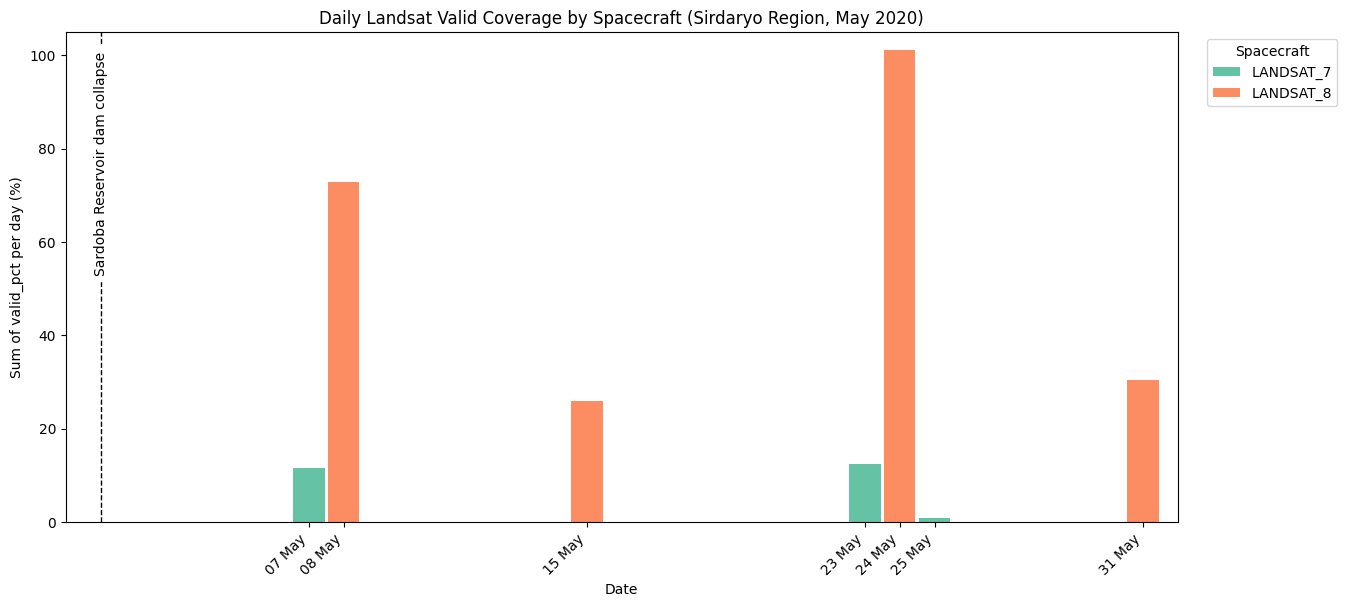

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import AutoDateLocator, DateFormatter
from pathlib import Path

# --- Config ---
csv_path = Path("/Users/Ivan_Divilkovskiy/Downloads/Syrdarya_flood/data sources/SirdaryoADM1_Landsat_May2020_valid_coverage.csv")
start = pd.Timestamp("2020-04-30")
end   = pd.Timestamp("2020-06-01")
event_date = pd.Timestamp("2020-05-01")
event_label = "Sardoba Reservoir dam collapse"

# --- Load ---
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# --- Robust date parsing (handle both 'DD/MM/YYYY' and ISO) ---
s = df["date"].astype(str).str.strip()
mask_slash = s.str.contains("/")
dates_slash = pd.to_datetime(s.where(mask_slash), format="%d/%m/%Y", errors="coerce")
dates_iso   = pd.to_datetime(s.where(~mask_slash), errors="coerce")
df["date"] = dates_slash.fillna(dates_iso)
df = df.dropna(subset=["date"])

# --- valid_pct to numeric (strip quotes/strays); scale to percent if 0..1 ---
valid_clean = df["valid_pct"].astype(str).str.replace(r"[^0-9.\-eE]", "", regex=True)
df["valid_pct"] = pd.to_numeric(valid_clean, errors="coerce").fillna(0.0)
if df["valid_pct"].max() <= 1.5:
    df["valid_pct"] *= 100.0

# --- Aggregate: daily x spacecraft_id -> stacked ---
stack = (
    df.groupby([df["date"].dt.date, "spacecraft_id"])["valid_pct"]
      .sum()
      .unstack(fill_value=0.0)
      .sort_index(axis=1)  # consistent legend/stack order
)
stack.index = pd.to_datetime(stack.index)

# Reindex to full day range
full_range = pd.date_range(start, end, freq="D")
stack = stack.reindex(full_range, fill_value=0.0)
meaningful_days = stack.index[stack.sum(axis=1) > 0]



# --- Plot (stacked daily bars) ---
fig, ax = plt.subplots(figsize=(16, 7))

# Colors
cols = list(stack.columns)
cmap = plt.get_cmap("Set2")
color_dict = {name: cmap(i % cmap.N) for i, name in enumerate(cols)}

# Stacked bars
bottoms = pd.Series(0.0, index=stack.index)
for name in cols:
    ax.bar(stack.index, stack[name].values, bottom=bottoms.values,
           label=name, color=color_dict[name], width=0.9, align="center")
    bottoms += stack[name]

# Event line + label (styled like your example)
ax.axvline(x=event_date, color="black", linestyle="--", linewidth=1)
ax.text(event_date, ax.get_ylim()[1]*0.95, event_label, rotation=90,
        va="top", ha="center", fontsize=10, backgroundcolor="white")

# Formatting
ax.set_title("Daily Landsat Valid Coverage by Spacecraft (Sirdaryo Region, May 2020)")
ax.set_xlabel("Date")
ax.set_ylabel("Sum of valid_pct per day (%)")
ax.set_xlim(start, end)
ax.set_ylim(0, 105)  # keep your 0–100 axis; raise if you want to avoid clipping in other cases

locator = AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(DateFormatter("%d %b"))
ax.set_xticks(meaningful_days)
ax.set_xticklabels([d.strftime("%d %b") for d in meaningful_days], rotation=45, ha="right")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Legend outside, like your template
ax.legend(title="Spacecraft", bbox_to_anchor=(1.02, 1), loc="upper left")

# Avoid tight_layout warnings; give margins instead
plt.subplots_adjust(right=0.82, bottom=0.2, top=0.9)

plt.show()


![Satellite coverage](/images/Sirdaryo_coverage.gif)

*Satellite coverage by days in May. Satellite images Landsat7, Landsat8*

This exercise shows the fundamental limitation of this method: while it can capture long-term inundation, it is likely to miss floods that recede in days or even weeks. In situations similar to flash floods, this method would only provide us with the minimum estimate, or even miss those completely.